In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function

In [2]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67140322

### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.33    # dispersal rate from release site to household
rho = 0.33     # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

rel_fem = 8
rel_male = 2
delta_rel = 50

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold"

"relhhold"

In [3]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time

## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    #:rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 24 entries:
  :b       => 0.54
  :alpha   => 0.1
  :gamma   => 0.33
  :m_free0 => 0
  :rho     => 0.33
  :t_start => 0
  :h       => 0.756404
  :rel_t   => 150
  :male_w0 => 0
  :fem_m0  => 8
  :K       => 30
  :phi     => 0.85
  :fem_w0  => 0
  :d       => 0.12
  :k       => 0.3
  :v       => 1
  :u       => 1
  :male_m0 => 8
  :tau     => 0.33
  ⋮        => ⋮

In [4]:
### Convert dispersal parameters to a string and remove the decimal point
## We will use this to call the correct data files
rho_str = replace(string(rho), "." => "")
tau_str = replace(string(tau), "." => "")
gamma_str = replace(string(gamma), "." => "")
alpha_str = replace(string(alpha), "." => "")

"01"

In [5]:
df_m = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "m_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_male)_$(rel_fem)_$(rel_type).csv"), DataFrame)
df_w = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "w_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_male)_$(rel_fem)_$(rel_type).csv"), DataFrame)
m_array = Array(df_m) # convert to array
w_array = Array(df_w)
df_free_m = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "free_m_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_male)_$(rel_fem)_$(rel_type).csv"), DataFrame)
df_free_w = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "free_w_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_male)_$(rel_fem)_$(rel_type).csv"), DataFrame)
free_m_array = Array(df_free_m)
free_w_array = Array(df_free_w)

1001×100 Matrix{Float64}:
   0.0    0.0    0.0    0.0    0.0  …    0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0  …    0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   ⋮                                ⋱    ⋮                         
 313.0  235.0  288.0  249.0  245.0     262.0  280.0  287.0  297.0  291.0
 274.0  247.0  283.0  242.0  230.0     240.0  276.0  281.0  291.0  280.0
 296.0  261.0  252.0  242.0  2

Needs finishing, want to calculate probability of wolbachia invasion i.e. complete wildtype extinction in the population for each household single release ration. We use csv file to extract write data files for each scenario....

In [6]:
# Read the CSV file into a DataFrame
JOBS_DF = CSV.read("mixed_single_rel.csv", DataFrame)

# Function to find the JOB_ID for given rel_fem and rel_male
function find_job_id(df::DataFrame, rel_fem_value, rel_male_value)
    found = false
    for row in eachrow(df)
        if !ismissing(row[Symbol("job no.")]) &&
           row[Symbol("no. females")] == rel_fem_value && row[Symbol("no. males")] == rel_male_value
            return row[Symbol("job no.")]
            found = true
            break
        else
            continue
        end
    end # Return nothing if no matching row is found
    if !found
        return nothing
    end
end

# Example usage
rel_fem_value = 0  # Replace with the desired rel_fem value
rel_male_value = 1  # Replace with the desired rel_male value

job_id = find_job_id(JOBS_DF, rel_fem_value, rel_male_value)
println(job_id)


67137380


In [7]:
### CHANGE BACK TO ZEROS ANYWHERE FOR SUCCESSFULL INVASION?
# Function to count columns with zero
function count_columns_with_zero(df::DataFrame)
    count_zeros = 0
    for col in eachcol(df)
        if 0.0 in col
            count_zeros += 1
        end
    end
    return count_zeros
end

ratio = zeros(11,11)
for male in 0:10
    for fem in 0:10
        JOB_ID = find_job_id(JOBS_DF, fem, male)
        println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing
            df_m = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "m_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
            # Calculate the ratio
            ratio[male+1,fem+1] = count_columns_with_zero(df_m) / size(df_m, 2)
            println(ratio[male+1,fem+1])
        end
    end
end

0  0  nothing
1  0  67137376
0.37
2  0  67137382
0.95
3  0  67137441
1.0
4  0  67137517
1.0
5  0  67137527
1.0
6  0  67137545
1.0
7  0  67137559
1.0
8  0  67137572
1.0
9  0  67140464
1.0
10  0  67140465
1.0
0  1  67137380
0.0
1  1  67137381
0.41
2  1  67137386
0.99
3  1  67137515
1.0
4  1  67137520
1.0
5  1  67137531
1.0
6  1  67137551
1.0
7  1  67140312
1.0
8  1  67137575
1.0
9  1  67140320
1.0
10  1  67137582
1.0
0  2  67137383
0.0
1  2  67137437
0.68
2  2  67137443
1.0
3  2  67137523
1.0
4  2  67137543
1.0
5  2  67137557
1.0
6  2  67137566
1.0
7  2  67140314
1.0
8  2  67140322
1.0
9  2  67140430
1.0
10  2  67140472
1.0
0  3  67137442
0.0
1  3  67137516
0.7
2  3  67137522
1.0
3  3  67140473
1.0
4  3  67137558
1.0
5  3  67137570
1.0
6  3  67140316
1.0
7  3  67140427
1.0
8  3  67140466
1.0
9  3  67140474
1.0
10  3  67140475
1.0
0  4  67137518
0.0
1  4  67137519
0.81
2  4  67137542
1.0
3  4  67137544
1.0
4  4  67137571
1.0
5  4  67137577
1.0
6  4  67140429
1.0
7  4  67140468
1.0
8  4  6

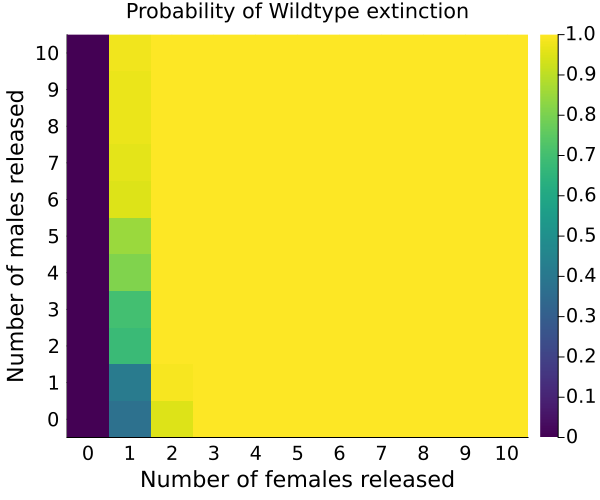

In [53]:
using Plots
gr()  # or your preferred backend

heatmap_plot = heatmap(
    ratio,
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Probability of Wildtype extinction", 
    color = :viridis,
    xticks = (1:11, 0:10), 
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    foreground_color_grid = :black  # Set grid (tick line) color
)

savefig(heatmap_plot, "single_mix_rel_inv_prob.pdf")
heatmap_plot


In [26]:
av_wolbs = zeros(11,11)
sum_w = 0
for male in 0:10
    for fem in 0:10
        sum_w = 0
        JOB_ID = find_job_id(JOBS_DF, fem, male)
        #println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing
            for i in 1:num_simulations
                fem_w_hholds = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "fem_w_hholds_$(i)_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
                male_w_hholds = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "male_w_hholds_$(i)_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
                sum_w += (sum(male_w_hholds[:,end]) + sum(fem_w_hholds[:,end]))/H
            end
        end
        av_wolbs[male+1,fem+1] = sum_w / num_simulations
    end
end

In [13]:
maximum(av_wolbs)

17.435400000000005

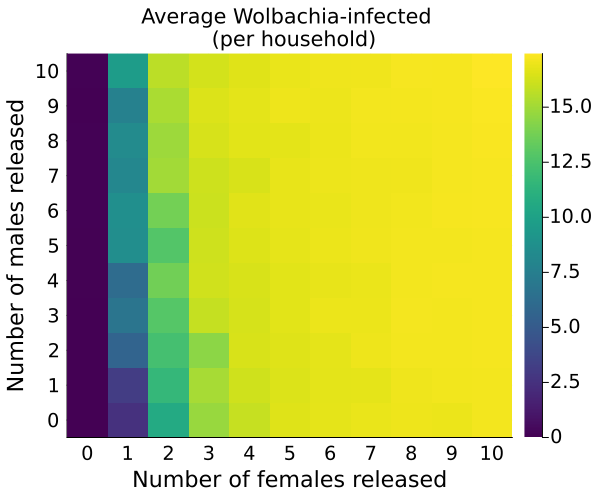

In [42]:
using Plots
using Measures
gr()  # or your preferred backend

heatmap_plot = heatmap(
    av_wolbs,
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Average Wolbachia-infected \n (per household)", 
    color = :viridis,
    xticks = (1:11, 0:10), 
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    foreground_color_grid = :black,  # Set grid (tick line) color
    right_margin=5mm     # Add extra margin to ensure the color bar is fully visible
)

savefig(heatmap_plot, "single_mix_rel_av_wolbs.pdf")
heatmap_plot

In [43]:
function count_columns_ends_with_zero(df::DataFrame)
    count_zeros = 0
    for col in eachcol(df)
        if col[end] == 0.0
            count_zeros += 1
        end
    end
    return count_zeros
end

av_hholds = zeros(11,11)
hhold_count = 0
for male in 0:10
    for fem in 0:10
        hhold_count = 0
        JOB_ID = find_job_id(JOBS_DF, fem, male)
        #println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing
            for i in 1:num_simulations
                fem_m_hholds = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "fem_m_hholds_$(i)_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
                male_m_hholds = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)", "male_m_hholds_$(i)_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
                sum_m = fem_m_hholds .+ male_m_hholds
                hhold_count += count_columns_ends_with_zero(sum_m)
            end
        end
        av_hholds[male+1,fem+1] = hhold_count / num_simulations
    end
end

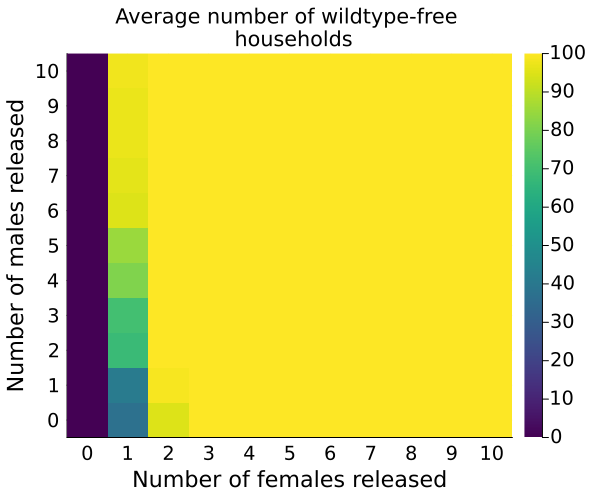

In [47]:
using Plots
using Measures
gr()  # or your preferred backend

heatmap_plot = heatmap(
    av_hholds,
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Average number of wildtype-free \n households", 
    color = :viridis,
    xticks = (1:11, 0:10), 
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    foreground_color_grid = :black,  # Set grid (tick line) color
    right_margin=5mm     # Add extra margin to ensure the color bar is fully visible
)

savefig(heatmap_plot, "single_mix_rel_av_hholds.pdf")
heatmap_plot

In [15]:
wolb_pers = zeros(11,11)

for male in 0:10
    for fem in 0:10
        JOB_ID = find_job_id(JOBS_DF, fem, male)
        println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing
            df_track_fem_m = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_fem_m_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_relhhold.csv"), DataFrame)
            df_track_male_m = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_male_m_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_relhhold.csv"), DataFrame)
            df_track_fem_w = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_fem_w_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_relhhold.csv"), DataFrame)
            df_track_male_w = CSV.read(joinpath("testing_gen_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_male_w_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(male)_$(fem)_relhhold.csv"), DataFrame)
        else 
            continue
        end
        wolb_persist = df_track_fem_w .+ df_track_male_w # sum males and females
        n_rows, n_cols = size(wolb_persist)
        indices_zero_after_non_zero = fill(t_end+1, n_cols)  # Initialize with t_end to indicate no such zero found
        indices_first_non_zero = fill(t_end+1, n_cols)      # Initialize with t_end to indicate no non-zero found

        for col in 1:n_cols  # finds index where wolbachia first introduced and index where it goes extinct (if does)
            found_non_zero = false
            for row in 1:n_rows
                if wolb_persist[row, col] != 0
                    if !found_non_zero
                        indices_first_non_zero[col] = row
                        found_non_zero = true
                    end
                elseif found_non_zero && wolb_persist[row, col] == 0
                    indices_zero_after_non_zero[col] = row
                    break
                end
            end
        end

        wolb_pers[male+1,fem+1] = mean(indices_zero_after_non_zero - indices_first_non_zero)
    end
end

0  0  nothing
1  0  67137376
2  0  67137382
3  0  67137441
4  0  67137517
5  0  67137527
6  0  67137545
7  0  67137559
8  0  67137572
9  0  67140464
10  0  67140465
0  1  67137380
1  1  67137381
2  1  67137386
3  1  67137515
4  1  67137520
5  1  67137531
6  1  67137551
7  1  67140312
8  1  67137575
9  1  67140320
10  1  67137582
0  2  67137383
1  2  67137437
2  2  67137443
3  2  67137523
4  2  67137543
5  2  67137557
6  2  67137566
7  2  67140314
8  2  67140322
9  2  67140430
10  2  67140472
0  3  67137442
1  3  67137516
2  3  67137522
3  3  67140473
4  3  67137558
5  3  67137570
6  3  67140316
7  3  67140427
8  3  67140466
9  3  67140474
10  3  67140475
0  4  67137518
1  4  67137519
2  4  67137542
3  4  67137544
4  4  67137571
5  4  67137577
6  4  67140429
7  4  67140468
8  4  67140477
9  4  67140478
10  4  67140479
0  5  67137528
1  5  67137530
2  5  67137556
3  5  67137567
4  5  67137576
5  5  67137580
6  5  67140470
7  5  67140487
8  5  67140488
9  5  67140489
10  5  67140490
0  6 

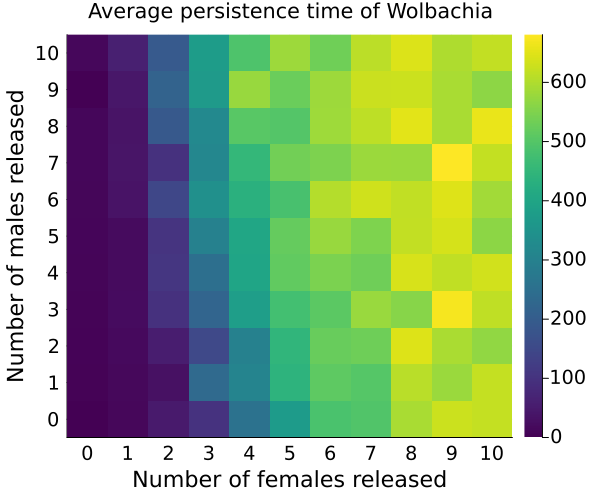

In [16]:
using Plots
using Measures
gr()  # or your preferred backend

heatmap_plot = heatmap(
    wolb_pers,
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Average persistence time of Wolbachia", 
    color = :viridis,
    xticks = (1:11, 0:10), 
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    foreground_color_grid = :black,  # Set grid (tick line) color
    right_margin=5mm     # Add extra margin to ensure the color bar is fully visible
)

savefig(heatmap_plot, "single_mix_wolb_pers.pdf")
heatmap_plot

In [15]:
wolb_pers

11×11 Matrix{Float64}:
 0.0   0.0     0.0     0.0     0.0   …    0.0     0.0     0.0     0.0
 0.0  12.48   28.46  232.86  307.21     500.48  609.97  578.46  620.87
 0.0  15.67   51.78  148.83  296.46     530.97  646.04  594.6   569.33
 0.0  18.92   94.81  218.77  378.69     577.23  558.51  672.13  616.24
 0.0  18.44  104.39  247.4   398.48     532.25  640.12  616.71  633.87
 0.0  18.3   100.17  296.28  403.06  …  549.7   618.4   638.08  564.62
 0.0  32.69  143.84  340.79  433.02     631.94  617.78  647.31  586.44
 0.0  35.69   93.64  313.43  452.46     579.64  578.94  680.64  620.31
 0.0  34.0   189.14  319.37  505.32     613.87  652.71  593.96  660.0
 0.0  40.33  213.09  369.28  576.9      626.39  628.33  593.7   565.55
 0.0  57.71  191.32  374.7   491.97  …  611.53  644.98  599.23  618.44